# Moral AI - New Approach (Scenario-Level)
We are switching from user-level aggregation to scenario-level prediction because we want to predict a new user's choice in a specific scenario, and aggregates remove scenario context and can leak target information.

## Section 1 - Load the Two Base Datasets

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

MM_PATH = Path("SharedResponsesSurvey.csv")
BRIDGE_PATH = Path("bridge.csv")
HF_DATASET_ID = "ecorbari/IPIP120-SCORES"

pd.set_option("display.max_columns", 50)


def load_personality_from_hf(dataset_id: str = HF_DATASET_ID) -> pd.DataFrame:
    """Load the first available split from a Hugging Face dataset."""
    ds = load_dataset(dataset_id)
    split = next(iter(ds.keys()))
    return ds[split].to_pandas()


if not MM_PATH.exists():
    raise FileNotFoundError(f"Missing file: {MM_PATH}")

# Dataset 1 preview
mm_head = pd.read_csv(MM_PATH, nrows=5)
mm_head

# Dataset 2 preview (Hugging Face)
df_ipip = load_personality_from_hf()
df_ipip.head()

,case,sex,age,sec,min,hour,day,month,year,country,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,...,facet_dutifulness,facet_achievement_striving,facet_self_discipline,facet_cautiousness,extraversion,facet_friendliness,facet_gregariousness,facet_assertiveness,facet_activity_level,facet_excitement_seeking,facet_cheerfulness,agreeableness,facet_trust,facet_morality,facet_altruism,facet_cooperation,facet_modesty,facet_sympathy,neuroticism,facet_anxiety,facet_anger,facet_depression,facet_self_consciousness,facet_immoderation,facet_vulnerability
0,1,2,19,8,41,16,30,6,101,South Afr,5,4,5,4,4,2,5,5,4,4,2,4,4,4,4,...,54.892857,63.675297,41.888264,84.032423,56.493023,74.071748,65.945007,77.299926,12.265075,23.740125,66.964675,84.214345,73.438475,72.159605,67.393775,76.776519,74.954334,77.384533,35.573367,27.993157,11.549711,58.018551,39.725121,96.864432,11.048211
1,2,2,22,24,45,16,30,6,101,USA,5,4,4,2,5,5,5,4,5,4,4,4,5,5,4,...,44.963610,16.580116,84.633574,67.456166,80.144284,77.267973,94.271135,47.536294,96.065024,87.511279,5.776425,47.158018,13.978142,83.405900,89.448233,4.270395,69.646885,67.981348,66.998550,58.854938,89.843818,89.880570,57.486716,1.000000,80.327511
2,6,1,13,14,6,17,30,6,101,USA,2,4,2,2,4,4,5,4,3,2,2,4,2,2,4,...,14.383704,80.885654,99.646135,74.813500,80.931850,70.526550,86.659049,39.758576,92.707965,73.646661,65.158443,1.000000,7.526992,7.408120,2.417954,3.278791,24.018170,12.400848,22.577376,33.979027,86.802916,29.000871,7.509259,6.890607,15.131043
3,7,2,18,25,11,17,30,6,101,USA,3,4,3,2,5,4,4,4,3,3,2,5,4,4,5,...,78.953690,82.391009,83.566408,60.403585,84.255079,74.071748,81.190659,96.180870,97.498896,23.740125,56.848582,44.246158,27.248015,72.159605,54.492760,52.320264,38.542547,41.268613,12.466800,12.195029,57.719898,18.108659,8.870845,44.831762,5.285188
4,8,2,24,19,25,17,30,6,101,USA,4,4,4,5,4,2,3,4,4,4,3,3,5,5,4,...,44.963610,16.580116,43.843893,42.280102,50.534797,49.513820,59.439053,37.789326,41.578470,22.776857,88.517103,77.026790,83.907554,58.955730,66.457831,82.330021,50.199377,55.939489,26.353107,21.800273,7.899414,26.475441,38.817649,62.697315,53.029251


## Section 2 - Explain the Switch in Approach (Notebook Context)
- Old workflow: aggregate all choices per user and predict a user-level moral profile.
- New workflow: predict the choice for a specific scenario using personality and scenario context.
- Reason: aggregation hides scenario features and can introduce leakage when predicting a specific response.

## Section 3 - Basic Exploration: Dataset 1

In [16]:
MM_USECOLS = [
    "UserID",
    "ScenarioOrder",
    "Intervention",
    "PedPed",
    "Barrier",
    "CrossingSignal",
    "ScenarioType",
    "DefaultChoiceIsOmission",
    "NumberOfCharacters",
    "DiffNumberOFCharacters",
    "Saved",
    "UserCountry3",
    "Review_age",
    "Review_gender",
    "Review_income",
    "Review_education",
    "Review_political",
    "Review_religious",
]

SAMPLE_ROWS = 100_000  # sample for quick exploration
mm_sample = pd.read_csv(MM_PATH, usecols=MM_USECOLS, nrows=SAMPLE_ROWS, low_memory=False)

mm_sample.shape
mm_sample.head()
list(mm_sample.columns)
mm_sample.isna().mean().sort_values(ascending=False).head(12)

numeric_cols = mm_sample.select_dtypes(include=[np.number]).columns
mm_sample[numeric_cols].describe().transpose()

c:\Users\User\Poli\AAD\.venv\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
UserID,100000.0,4.984046e+15,2.887167e+15,6.601630e+11,2.467605e+15,5.015118e+15,7.517256e+15,9.996893e+15
ScenarioOrder,100000.0,6.996900e+00,3.741394e+00,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.300000e+01
Intervention,100000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
PedPed,100000.0,4.522500e-01,4.977172e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Barrier,100000.0,2.155700e-01,4.112192e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
CrossingSignal,100000.0,6.874700e-01,8.571245e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00
DefaultChoiceIsOmission,89408.0,4.887818e-01,4.998769e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
NumberOfCharacters,100000.0,3.082340e+00,1.462505e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
DiffNumberOFCharacters,100000.0,5.767800e-01,1.155421e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
Saved,100000.0,4.591200e-01,4.983285e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


## Section 4 - Basic Exploration: Dataset 2

In [17]:
df_ipip.shape
df_ipip.head()
list(df_ipip.columns)
df_ipip.isna().mean().sort_values(ascending=False).head(12)

ipip_numeric = df_ipip.select_dtypes(include=[np.number])
ipip_numeric.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
case,410376.0,342583.207120,197971.282053,1.000000,171502.750000,341711.500000,511809.250000,690863.000000
sex,410376.0,1.589533,0.491919,1.000000,1.000000,2.000000,2.000000,2.000000
age,410376.0,24.933746,9.909991,10.000000,18.000000,21.000000,28.000000,99.000000
sec,410376.0,29.522131,17.310330,0.000000,15.000000,30.000000,45.000000,59.000000
min,410376.0,29.665063,17.283012,0.000000,15.000000,30.000000,45.000000,59.000000
...,...,...,...,...,...,...,...,...
facet_anger,410376.0,45.279672,29.518447,1.000000,19.921776,43.806995,70.012393,99.581700
facet_depression,410376.0,41.414211,28.401918,3.060803,18.108659,34.578102,61.789937,99.674817
facet_self_consciousness,410376.0,47.068191,28.464582,1.000000,22.421631,48.122356,68.039731,99.667785
facet_immoderation,410376.0,47.197800,28.474458,1.000000,24.233689,44.831762,69.038309,99.670235


## Section 5 - Load the Bridge Dataset (bridge.csv)

In [18]:
if not BRIDGE_PATH.exists():
    raise FileNotFoundError(f"Missing file: {BRIDGE_PATH}")

bridge_df = pd.read_csv(BRIDGE_PATH)
bridge_df.head()
bridge_df.dtypes

UserID                     int64
ScenarioOrder              int64
Intervention               int64
PedPed                     int64
Barrier                    int64
CrossingSignal             int64
AttributeLevel               str
ScenarioTypeStrict           str
ScenarioType                 str
DefaultChoice                str
NonDefaultChoice             str
DefaultChoiceIsOmission    int64
NumberOfCharacters         int64
DiffNumberOFCharacters     int64
Saved                      int64
Review_age                 int64
Review_gender                str
openness                   int64
conscientiousness          int64
extraversion               int64
agreeableness              int64
neuroticism                int64
dtype: object

## Section 6 - Clean and Prepare the Three Datasets

In [19]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    if "userid" in df.columns:
        df = df.rename(columns={"userid": "user_id"})
    return df


def normalize_big5_columns(df: pd.DataFrame) -> pd.DataFrame:
    aliases = {
        "openness": ["openness", "big5_openness", "o", "open"],
        "conscientiousness": ["conscientiousness", "big5_conscientiousness", "c", "consc"],
        "extraversion": ["extraversion", "big5_extraversion", "e", "extra"],
        "agreeableness": ["agreeableness", "big5_agreeableness", "a", "agree"],
        "neuroticism": ["neuroticism", "big5_neuroticism", "n", "neuro"],
    }
    available = {c.lower(): c for c in df.columns}
    resolved = {}
    for target, alias_list in aliases.items():
        for alias in alias_list:
            if alias.lower() in available:
                resolved[target] = pd.to_numeric(df[available[alias.lower()]], errors="coerce")
                break
    missing = sorted(set(aliases) - set(resolved))
    if missing:
        raise ValueError("Missing Big Five columns: " + ", ".join(missing))

    result = pd.DataFrame(resolved).dropna().reset_index(drop=True)

    if "sex" in available:
        result["sex"] = df[available["sex"]].iloc[result.index].values
    if "age" in available:
        result["age"] = pd.to_numeric(df[available["age"]].iloc[result.index], errors="coerce").values
    if "country" in available:
        result["country"] = df[available["country"]].iloc[result.index].astype(str).str.strip().values

    return result


mm_sample_clean = standardize_columns(mm_sample)
mm_sample_clean = mm_sample_clean.rename(
    columns={
        "review_gender": "gender",
        "review_age": "age",
        "review_income": "income",
        "review_education": "education",
        "review_political": "political",
        "review_religious": "religious",
        "usercountry3": "country",
    }
)

bridge_clean = standardize_columns(bridge_df)
bridge_clean = bridge_clean.rename(
    columns={
        "review_gender": "gender",
        "review_age": "age",
    }
)

ipip_clean = normalize_big5_columns(df_ipip)

for col in ["age", "income", "political", "religious"]:
    if col in mm_sample_clean.columns:
        mm_sample_clean[col] = pd.to_numeric(mm_sample_clean[col], errors="coerce")

for col in [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
    "age",
]:
    if col in bridge_clean.columns:
        bridge_clean[col] = pd.to_numeric(bridge_clean[col], errors="coerce")

if "gender" in mm_sample_clean.columns:
    mm_sample_clean["gender"] = mm_sample_clean["gender"].astype(str).str.strip().str.lower()
if "gender" in bridge_clean.columns:
    bridge_clean["gender"] = bridge_clean["gender"].astype(str).str.strip().str.lower()
if "country" in mm_sample_clean.columns:
    mm_sample_clean["country"] = mm_sample_clean["country"].astype(str).str.strip().str.lower()
if "country" in ipip_clean.columns:
    ipip_clean["country"] = ipip_clean["country"].astype(str).str.strip().str.lower()

if "user_id" in bridge_clean.columns:
    bridge_clean["user_id"] = bridge_clean["user_id"].astype(str)
if "user_id" in mm_sample_clean.columns:
    mm_sample_clean["user_id"] = mm_sample_clean["user_id"].astype(str)

## Section 7 - Align Keys and Merge for Correlation
This is a statistical match using age, sex, and country where available; it does not link the same individual across datasets.

In [20]:
def link_profiles_with_personality(
    profiles: pd.DataFrame,
    personality_df: pd.DataFrame,
    seed: int = 42,
    age_tolerance: int = 5,
    use_country: bool = True,
    show_progress: bool = False,
) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    big5 = normalize_big5_columns(personality_df)

    big5["sex_str"] = big5["sex"].map({1: "female", 2: "male"}).fillna(big5["sex"].astype(str).str.lower())
    big5["country_norm"] = big5["country"].astype(str).str.strip().str.lower()

    iterator = profiles.iterrows()
    if show_progress:
        try:
            from tqdm.auto import tqdm

            iterator = tqdm(iterator, total=len(profiles), desc="Linking profiles", unit="user")
        except Exception:
            pass

    linked_rows = []
    match_strategy = {}

    for idx, profile in iterator:
        has_sex = "gender" in profile.index and "sex_str" in big5.columns
        has_age = "age" in profile.index and "age" in big5.columns
        has_country = "country" in profile.index and "country_norm" in big5.columns

        profile_gender = str(profile.get("gender", "")).strip().lower() if has_sex else ""
        profile_country = str(profile.get("country", "")).strip().lower() if has_country else ""

        candidates = pd.DataFrame()
        strategy = "unmatched_no_fallback"

        if (
            use_country
            and has_country
            and has_sex
            and has_age
            and profile_gender in ["male", "female"]
            and profile_country not in ["", "unknown"]
        ):
            candidates = big5[
                (big5["country_norm"] == profile_country)
                & (big5["sex_str"] == profile_gender)
                & (big5["age"] >= profile["age"] - age_tolerance)
                & (big5["age"] <= profile["age"] + age_tolerance)
            ]
            strategy = "country_sex_age_stratified"

        if len(candidates) == 0 and has_sex and has_age and profile_gender in ["male", "female"]:
            candidates = big5[
                (big5["sex_str"] == profile_gender)
                & (big5["age"] >= profile["age"] - age_tolerance)
                & (big5["age"] <= profile["age"] + age_tolerance)
            ]
            strategy = "sex_age_stratified"

        if len(candidates) == 0 and has_age:
            candidates = big5[
                (big5["age"] >= profile["age"] - age_tolerance)
                & (big5["age"] <= profile["age"] + age_tolerance)
            ]
            strategy = "age_stratified"

        if len(candidates) > 0:
            selected = candidates.iloc[rng.choice(len(candidates))]
        else:
            selected = pd.Series({col: np.nan for col in big5.columns})
            strategy = "unmatched_no_fallback"

        linked_rows.append(selected)
        match_strategy[idx] = strategy

    big5_linked = pd.DataFrame(linked_rows).reset_index(drop=True)
    rename_map = {
        c: f"ipip_{c}"
        for c in ["age", "sex", "sex_str", "country", "country_norm"]
        if c in big5_linked.columns
    }
    big5_linked = big5_linked.rename(columns=rename_map)

    linked = pd.concat([profiles.reset_index(drop=True), big5_linked], axis=1)

    strategy_counts = pd.Series(match_strategy.values()).value_counts().to_dict()
    report = {
        "strategy": "stratified_country_sex_age_no_fallback",
        "use_country": bool(use_country),
        "age_tolerance": int(age_tolerance),
        "match_strategies": strategy_counts,
        "n_profiles": int(len(profiles)),
        "n_linked_rows": int(len(linked)),
        "n_unmatched": int(strategy_counts.get("unmatched_no_fallback", 0)),
        "personality_source": "huggingface",
        "hf_dataset": HF_DATASET_ID,
    }
    return linked, report


def link_by_demographics(
    left: pd.DataFrame,
    right: pd.DataFrame,
    right_prefix: str | None = None,
    seed: int = 42,
    age_tolerance: int = 5,
    use_country: bool = True,
    drop_keys: bool = True,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    left_work = left.copy()
    right_work = right.copy()

    if "gender" in left_work.columns:
        left_work["gender_norm"] = left_work["gender"].astype(str).str.strip().str.lower()
    if "gender" in right_work.columns:
        right_work["gender_norm"] = right_work["gender"].astype(str).str.strip().str.lower()

    if "country" in left_work.columns:
        left_work["country_norm"] = left_work["country"].astype(str).str.strip().str.lower()
    if "country" in right_work.columns:
        right_work["country_norm"] = right_work["country"].astype(str).str.strip().str.lower()

    right_out = right_work.copy()
    if right_prefix:
        rename_cols = {
            c: f"{right_prefix}{c}"
            for c in right_out.columns
            if c not in ["age", "gender", "country", "gender_norm", "country_norm"]
        }
        right_out = right_out.rename(columns=rename_cols)
    if drop_keys:
        right_out = right_out.drop(columns=["age", "gender", "country", "gender_norm", "country_norm"], errors="ignore")

    matched_rows = []
    for _, row in left_work.iterrows():
        candidates = right_work

        if "gender_norm" in right_work.columns and row.get("gender_norm") in ["male", "female"]:
            candidates = candidates[candidates["gender_norm"] == row.get("gender_norm")]
        if "age" in right_work.columns and pd.notna(row.get("age")):
            candidates = candidates[
                (candidates["age"] >= row.get("age") - age_tolerance)
                & (candidates["age"] <= row.get("age") + age_tolerance)
            ]
        if (
            use_country
            and "country_norm" in right_work.columns
            and row.get("country_norm") not in ["", "unknown", "nan", None]
        ):
            candidates = candidates[candidates["country_norm"] == row.get("country_norm")]

        if len(candidates) == 0:
            candidates = right_work
            if "gender_norm" in right_work.columns and row.get("gender_norm") in ["male", "female"]:
                candidates = candidates[candidates["gender_norm"] == row.get("gender_norm")]
            if "age" in right_work.columns and pd.notna(row.get("age")):
                candidates = candidates[
                    (candidates["age"] >= row.get("age") - age_tolerance)
                    & (candidates["age"] <= row.get("age") + age_tolerance)
                ]

        if len(candidates) == 0 and "age" in right_work.columns and pd.notna(row.get("age")):
            candidates = right_work[
                (right_work["age"] >= row.get("age") - age_tolerance)
                & (right_work["age"] <= row.get("age") + age_tolerance)
            ]

        if len(candidates) > 0:
            picked = candidates.iloc[rng.choice(len(candidates))]
            picked_out = right_out.loc[picked.name]
        else:
            picked_out = pd.Series({c: np.nan for c in right_out.columns})

        matched_rows.append(picked_out)

    left_out = left_work.drop(columns=["gender_norm", "country_norm"], errors="ignore")
    matched = pd.concat(
        [left_out.reset_index(drop=True), pd.DataFrame(matched_rows).reset_index(drop=True)],
        axis=1,
    )
    return matched


scenario_cols = [
    "scenarioorder",
    "intervention",
    "pedped",
    "barrier",
    "crossingsignal",
    "scenariotype",
    "defaultchoiceisomission",
    "numberofcharacters",
    "diffnumberofcharacters",
    "saved",
]

demo_cols = [
    c
    for c in ["age", "gender", "country", "income", "education", "political", "religious"]
    if c in mm_sample_clean.columns
]

mm_cols = [c for c in ["user_id"] + scenario_cols + demo_cols if c in mm_sample_clean.columns]
mm_scenario = mm_sample_clean[mm_cols].copy()
mm_scenario = mm_scenario.dropna(subset=["age", "gender"], how="any")

CORR_SAMPLE = 30_000
if len(mm_scenario) > CORR_SAMPLE:
    mm_scenario = mm_scenario.sample(n=CORR_SAMPLE, random_state=42)

linked_mm_ipip, link_report = link_profiles_with_personality(
    mm_scenario,
    ipip_clean,
    seed=42,
    age_tolerance=5,
    use_country=True,
    show_progress=False,
)
link_report

bridge_cols = [
    c
    for c in [
        "age",
        "gender",
        "country",
        "openness",
        "conscientiousness",
        "extraversion",
        "agreeableness",
        "neuroticism",
    ]
    if c in bridge_clean.columns
]
bridge_personality = bridge_clean[bridge_cols].dropna(subset=["age", "gender"], how="any")

merged = link_by_demographics(
    linked_mm_ipip,
    bridge_personality,
    right_prefix="bridge_",
    seed=42,
    age_tolerance=5,
    use_country="country" in bridge_personality.columns,
    drop_keys=True,
)

bridge_coverage = merged.filter(like="bridge_").notna().mean().sort_values(ascending=False)
bridge_coverage.head(10)

merged.shape

(30000, 33)

## Section 8 - Correlation Analysis Across Demographics + Bridge Data

In [21]:
corr_df = merged.copy()

gender_col = None
for candidate in ["gender", "mm_gender", "bridge_gender"]:
    if candidate in corr_df.columns:
        gender_col = candidate
        break

if gender_col:
    gender_map = {"male": 1, "female": 0, "other": 2, "unknown": np.nan}
    corr_df[f"{gender_col}_code"] = (
        corr_df[gender_col].astype(str).str.lower().map(gender_map)
    )

numeric_df = corr_df.select_dtypes(include=[np.number]).copy()

numeric_df = numeric_df.loc[:, numeric_df.notna().mean() >= 0.3]
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]

corr_pearson = numeric_df.corr()
corr_spearman = numeric_df.corr(method="spearman")
corr = corr_spearman

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
cor_pairs = upper.stack()
cor_pairs = cor_pairs.reindex(cor_pairs.abs().sort_values(ascending=False).index)

pair_df = cor_pairs.head(20).reset_index()
pair_df.columns = ["var1", "var2", "spearman"]
pair_df["pearson"] = [
    corr_pearson.loc[v1, v2] for v1, v2 in zip(pair_df["var1"], pair_df["var2"])
]

pair_df

,var1,var2,spearman,pearson
0,ipip_sex,gender_code,1.000000,1.000000
1,age,ipip_age,0.885123,0.951231
2,age,bridge_conscientiousness,0.797626,0.761459
3,ipip_age,bridge_conscientiousness,0.706524,0.694417
4,bridge_conscientiousness,bridge_neuroticism,-0.571283,-0.511368
5,bridge_neuroticism,gender_code,0.535249,0.510250
6,ipip_sex,bridge_neuroticism,0.524494,0.500013
7,age,bridge_agreeableness,0.523343,0.593901
8,bridge_conscientiousness,bridge_agreeableness,0.515245,0.517387
9,extraversion,neuroticism,-0.497888,-0.506742


## Section 9 - Visualize Correlation Results

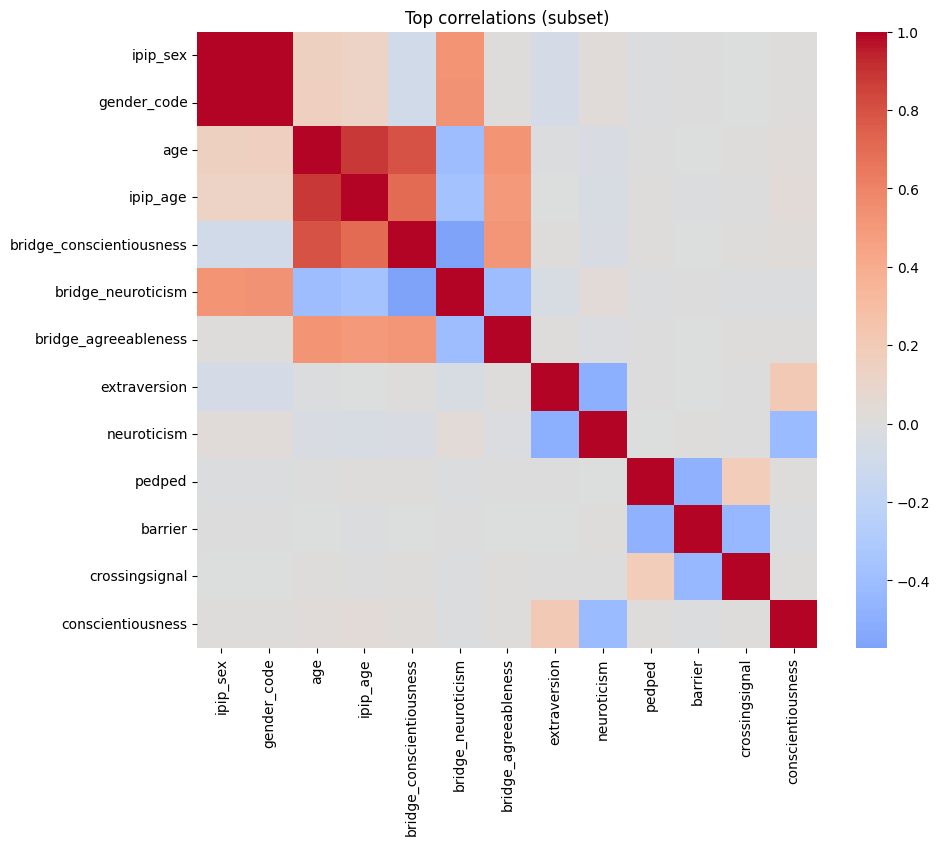

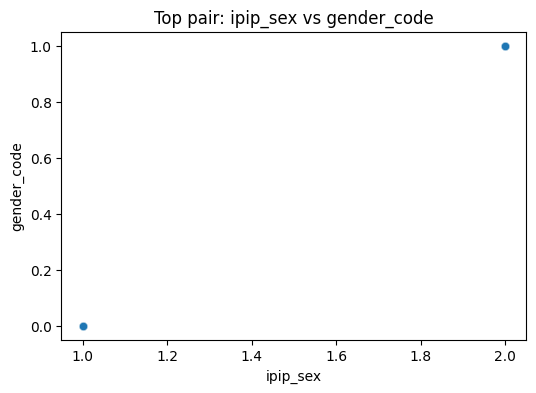

In [22]:
top_pairs = cor_pairs.head(15)

top_vars = pd.Index([v for pair in top_pairs.index for v in pair]).unique()
if len(top_vars) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr.loc[top_vars, top_vars], annot=False, cmap="coolwarm", center=0)
    plt.title("Top correlations (subset)")
    plt.show()

if len(top_pairs) > 0:
    x_var, y_var = top_pairs.index[0]
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=corr_df, x=x_var, y=y_var, alpha=0.4)
    plt.title(f"Top pair: {x_var} vs {y_var}")
    plt.show()

## Section 10 - How Big Five Traits Influence Choices
This section estimates how the Big Five personality traits relate to moral choices (scenario-level). We compute Spearman correlations and fit simple logistic regressions for binary choices, controlling for age and gender where available.

Detected trait columns (trait -> column):
{'openness': 'openness', 'conscientiousness': 'conscientiousness', 'extraversion': 'extraversion', 'agreeableness': 'agreeableness', 'neuroticism': 'neuroticism'}
Detected targets: ['saved', 'intervention', 'pedped', 'barrier']


c:\Users\User\Poli\AAD\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\User\Poli\AAD\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\User\Poli\AAD\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\User\Poli\AAD\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users

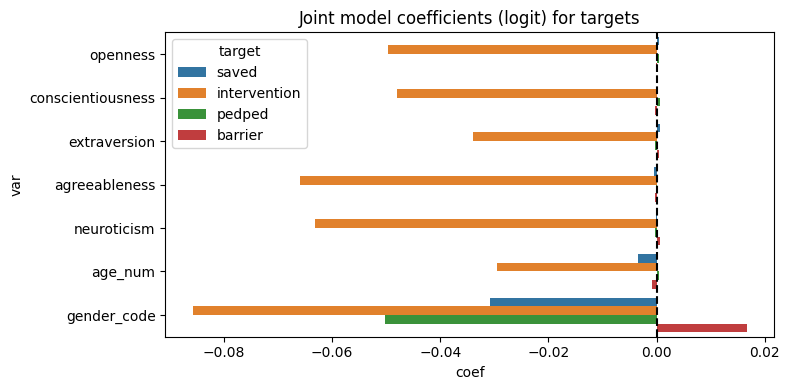

,target,trait,trait_col,n,spearman_rho,spearman_p,logit
0,pedped,conscientiousness,conscientiousness,29827,0.010051,0.082579,"{'params': {'const': -0.19631155432457148, 'co..."
1,saved,extraversion,extraversion,29827,0.009127,0.114988,"{'params': {'const': -0.08243826863512367, 'ex..."
2,barrier,conscientiousness,conscientiousness,29827,-0.007669,0.185336,"{'params': {'const': -1.2577538648638538, 'con..."
3,barrier,neuroticism,neuroticism,29827,0.007405,0.200976,"{'params': {'const': -1.316144794444646, 'neur..."
4,pedped,neuroticism,neuroticism,29827,-0.005862,0.311330,"{'params': {'const': -0.14586256184073998, 'ne..."
5,barrier,agreeableness,agreeableness,29827,-0.004987,0.389070,"{'params': {'const': -1.263615138020663, 'agre..."
6,saved,agreeableness,agreeableness,29827,-0.004985,0.389259,"{'params': {'const': -0.033534501251907434, 'a..."
7,pedped,openness,openness,29827,0.004302,0.457543,"{'params': {'const': -0.17238480148410823, 'op..."
8,saved,neuroticism,neuroticism,29827,-0.003872,0.503739,"{'params': {'const': -0.03061002034205275, 'ne..."
9,saved,openness,openness,29827,0.003276,0.571510,"{'params': {'const': -0.060040366428448316, 'o..."


In [24]:
# Section 10 - Personality -> Choices analysis
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
import statsmodels.api as sm

# Detect trait columns (prefer IPIP then bridge then any matching suffix)
trait_keys = ['openness','conscientiousness','extraversion','agreeableness','neuroticism']
trait_cols = {}
for t in trait_keys:
    t_lower = t.lower()
    candidates = [c for c in merged.columns if c.lower() == t_lower or c.lower().endswith('_'+t_lower) or c.lower().startswith('ipip_'+t_lower) or c.lower().startswith('bridge_'+t_lower)]
    if candidates:
        trait_cols[t] = candidates[0]

print('Detected trait columns (trait -> column):')
print(trait_cols)

# Targets of interest (binary choices)
targets = [c for c in ['saved','intervention','pedped','barrier'] if c in merged.columns]
print('Detected targets:', targets)

# Prepare gender code and age if available
df_analysis = merged.copy()
if 'gender' in df_analysis.columns:
    df_analysis['gender_code'] = df_analysis['gender'].astype(str).str.lower().map({'male':1,'female':0}).astype('float')
elif 'mm_gender' in df_analysis.columns:
    df_analysis['gender_code'] = df_analysis['mm_gender'].astype(str).str.lower().map({'male':1,'female':0}).astype('float')

if 'age' in df_analysis.columns:
    df_analysis['age_num'] = pd.to_numeric(df_analysis['age'], errors='coerce')

results = []
for target in targets:
    for trait, col in trait_cols.items():
        sub = df_analysis[[target, col, 'age_num', 'gender_code']].copy()
        sub = sub.dropna(subset=[target, col])
        if len(sub) < 50:
            continue
        # Spearman
        try:
            rho, p = spearmanr(sub[col], sub[target], nan_policy='omit')
        except Exception:
            rho, p = (np.nan, np.nan)
        # Logistic regression if target is binary (0/1)
        lr_summary = None
        try:
            y = pd.to_numeric(sub[target], errors='coerce')
            if set(y.dropna().unique()) <= {0,1}:
                X = pd.DataFrame()
                X[col] = pd.to_numeric(sub[col], errors='coerce')
                if 'age_num' in sub.columns:
                    X['age_num'] = sub['age_num']
                if 'gender_code' in sub.columns:
                    X['gender_code'] = sub['gender_code']
                X = sm.add_constant(X)
                model = sm.Logit(y, X, missing='drop')
                res = model.fit(disp=False)
                params = res.params.to_dict()
                pvalues = res.pvalues.to_dict()
                odds = np.exp(res.params).to_dict()
                lr_summary = {'params':params, 'pvalues':pvalues, 'odds':odds}
        except Exception as e:
            lr_summary = {'error': str(e)}

        results.append({
            'target': target,
            'trait': trait,
            'trait_col': col,
            'n': len(sub),
            'spearman_rho': float(rho) if not np.isnan(rho) else None,
            'spearman_p': float(p) if not np.isnan(p) else None,
            'logit': lr_summary,
        })

res_df = pd.DataFrame(results).sort_values('spearman_rho', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
res_df.head(40)

# Plot coefficients from joint model (all traits together) for each target
joint_rows = []
for target in targets:
    cols = [trait_cols[t] for t in trait_cols if trait_cols.get(t)]
    use_cols = [c for c in cols if c in df_analysis.columns]
    sub = df_analysis[[target] + use_cols + ['age_num','gender_code']].dropna(subset=[target]+use_cols)
    if len(sub) < 100:
        continue
    y = pd.to_numeric(sub[target], errors='coerce')
    if not set(y.dropna().unique()) <= {0,1}:
        continue
    X = sub[use_cols].apply(pd.to_numeric, errors='coerce')
    if 'age_num' in sub.columns:
        X['age_num'] = sub['age_num']
    if 'gender_code' in sub.columns:
        X['gender_code'] = sub['gender_code']
    X = sm.add_constant(X)
    try:
        res = sm.Logit(y, X, missing='drop').fit(disp=False)
        params = res.params
        pvals = res.pvalues
        orrs = np.exp(params)
        for name in params.index:
            if name == 'const':
                continue
            joint_rows.append({'target': target, 'var': name, 'coef': params[name], 'p': pvals[name], 'odds': orrs[name]})
    except Exception:
        continue

joint_df = pd.DataFrame(joint_rows)
if not joint_df.empty:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, max(4, joint_df['var'].nunique()*0.5)))
    sns.barplot(data=joint_df, x='coef', y='var', hue='target')
    plt.axvline(0, color='k', linestyle='--')
    plt.title('Joint model coefficients (logit) for targets')
    plt.tight_layout()
    plt.show()

# Show top correlations table
res_df.head(40)

## Section 11 - Modeling: Predicting Choices from Personality + Scenario
This section builds a scenario-level prediction pipeline using Big Five traits + demographics + scenario attributes. It compares Logistic Regression, Random Forest, and HistGradientBoosting using cross-validation, then fits the best model on a user-grouped train/test split and reports standard metrics (accuracy, precision, recall, F1, ROC-AUC, AP, Brier, confusion matrix).

In [ ]:
# Section 11: Modeling pipeline
from sklearn.model_selection import GroupShuffleSplit, cross_validate, train_test_split, StratifiedKFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report, brier_score_loss
)
from sklearn.inspection import permutation_importance

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_SGK = True
except Exception:
    HAS_SGK = False


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


# --- 1) Select target and features ---
TARGET = 'saved'  # change if you prefer another target
if TARGET not in merged.columns:
    raise ValueError(f"Target column '{TARGET}' not found in merged dataframe")

# trait columns detected earlier in trait_cols dict
feature_traits = [trait_cols[t] for t in trait_cols if trait_cols.get(t) in merged.columns]
scenario_features = [c for c in ['intervention','pedped','barrier','crossingsignal','numberofcharacters','diffnumberofcharacters','scenariotype'] if c in merged.columns]
demo_features = [c for c in ['age','gender','country','income','education','political','religious'] if c in merged.columns]

FEATURE_COLS = feature_traits + scenario_features + demo_features
FEATURE_COLS = [c for c in FEATURE_COLS if c in merged.columns]

if len(FEATURE_COLS) == 0:
    raise ValueError('No usable features found for modeling')

print('Using features (count):', len(FEATURE_COLS))
print(FEATURE_COLS)

# Build analysis DataFrame
df_model = merged[[TARGET] + FEATURE_COLS + ['user_id']].copy() if 'user_id' in merged.columns else merged[[TARGET] + FEATURE_COLS].copy()
df_model = df_model.dropna(subset=[TARGET])

# Convert target to binary if needed
y_raw = pd.to_numeric(df_model[TARGET], errors='coerce')
if set(y_raw.dropna().unique()) <= {0,1}:
    df_model['y'] = y_raw.astype(int)
else:
    # fallback: threshold at median
    med = y_raw.median()
    df_model['y'] = (y_raw >= med).astype(int)
    print(f"Target not binary; using median threshold {med} to binarize")

# Clean infinite or oversized numeric values in features
df_model = df_model.replace([np.inf, -np.inf], np.nan)
for col in FEATURE_COLS:
    if col in df_model.columns and pd.api.types.is_numeric_dtype(df_model[col]):
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Drop rows missing all features
df_model = df_model.dropna(axis=0, subset=FEATURE_COLS, how='all')

# Drop all-NaN feature columns after cleaning
nan_cols = [c for c in FEATURE_COLS if df_model[c].notna().sum() == 0]
if nan_cols:
    print('Dropping all-NaN columns:', nan_cols)
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in nan_cols]
    df_model = df_model.drop(columns=nan_cols)

if df_model['y'].nunique() < 2:
    raise ValueError('Target has only one class after cleaning; cannot train models')

if 'user_id' in df_model.columns:
    groups = df_model['user_id'].astype(str)
else:
    groups = None

# Train/test split by user (if available) else stratified random
TEST_SIZE = 0.2
if groups is not None:
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
    train_idx, test_idx = next(gss.split(df_model, groups=groups))
else:
    train_idx, test_idx = train_test_split(
        df_model.index,
        test_size=TEST_SIZE,
        random_state=42,
        stratify=df_model['y'],
    )

train = df_model.loc[train_idx].reset_index(drop=True)
test = df_model.loc[test_idx].reset_index(drop=True)
print('Train/test sizes:', len(train), len(test))

# Preprocessing
numeric_features = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(df_model[c])]
categorical_features = [c for c in FEATURE_COLS if c not in numeric_features]

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', make_ohe())])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', cat_transformer, categorical_features)])

# Candidate estimators
candidates = {
    'logreg': LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    'rf': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    'hgb': HistGradientBoostingClassifier(random_state=42)
}

X_train = train[FEATURE_COLS]
y_train = train['y']
X_test = test[FEATURE_COLS]
y_test = test['y']

# If dataset large, sample for cross-val speed
CV_MAX = 40_000
if len(X_train) > CV_MAX:
    X_cv = X_train.sample(n=CV_MAX, random_state=42)
    y_cv = y_train.loc[X_cv.index]
else:
    X_cv = X_train
    y_cv = y_train

# Choose CV strategy
cv_groups = None
if groups is not None:
    group_values = groups.loc[X_cv.index]
    n_groups = group_values.nunique()
    n_splits = min(5, max(2, n_groups))
    if HAS_SGK and n_splits >= 2:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_groups = group_values
    else:
        cv = GroupKFold(n_splits=n_splits)
        cv_groups = group_values
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy','f1','roc_auc','average_precision']
cv_results = {}
for name, est in candidates.items():
    pipe = Pipeline(steps=[('pre', preprocessor), ('model', est)])
    try:
        scores = cross_validate(
            pipe,
            X_cv,
            y_cv,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False,
            error_score=np.nan,
            groups=cv_groups,
        )
        cv_results[name] = {m: float(np.nanmean(scores[f'test_{m}'])) for m in scoring}
    except Exception as e:
        cv_results[name] = {'error': str(e)}

print('CV results:')
print(cv_results)

# Choose best by roc_auc (fallback to average_precision then f1)
best_name = None
best_score = -1
for name, res in cv_results.items():
    if 'error' in res:
        continue
    score = res.get('roc_auc')
    if score is None or np.isnan(score):
        score = res.get('average_precision')
    if score is None or np.isnan(score):
        score = res.get('f1')
    if score is None or np.isnan(score):
        continue
    if score > best_score:
        best_score = score
        best_name = name

if best_name is None:
    print('All CV models failed or returned NaN scores; falling back to logreg')
    best_name = 'logreg'

print('Best candidate:', best_name, 'score:', best_score)

# Fit best model on full train and evaluate on test
best_pipe = Pipeline(steps=[('pre', preprocessor), ('model', candidates[best_name])])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

if hasattr(best_pipe.named_steps['model'], 'predict_proba'):
    y_proba = best_pipe.predict_proba(X_test)[:,1]
else:
    y_proba = None

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None and y_test.nunique() == 2 else None,
    'average_precision': average_precision_score(y_test, y_proba) if y_proba is not None and y_test.nunique() == 2 else None,
    'brier': brier_score_loss(y_test, y_proba) if y_proba is not None and y_test.nunique() == 2 else None,
}
metrics

print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, zero_division=0))

# Permutation importance (on test)
try:
    r = permutation_importance(best_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    try:
        feature_names = best_pipe.named_steps['pre'].get_feature_names_out()
    except Exception:
        feature_names = [f'feat_{i}' for i in range(len(r.importances_mean))]
    importances = pd.Series(r.importances_mean, index=feature_names).sort_values(ascending=False).head(20)
    print('\nTop permutation importances (first 20 features):')
    print(importances)
except Exception as e:
    print('Permutation importance failed:', e)

# Save model to outputs (optional)
try:
    import joblib
    OUT_MODEL = Path('outputs/best_model.pkl')
    OUT_MODEL.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(best_pipe, OUT_MODEL)
    print('Saved best model to', OUT_MODEL)
except Exception as e:
    print('Could not save model:', e)

Using features (count): 19
['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism', 'intervention', 'pedped', 'barrier', 'crossingsignal', 'numberofcharacters', 'diffnumberofcharacters', 'scenariotype', 'age', 'gender', 'country', 'income', 'education', 'political', 'religious']
Train/test sizes: 24019 5981
